# AI Job Market — Salary Benchmarks & KPI Analysis
**Author**: Rendy Herdianto
**Date**: 2026-03-31  
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook analyses salary benchmarks across AI/ML job postings, covering the dataset
spanning September 2023 – September 2025. It quantifies how compensation varies by experience
level, industry, company size, and job title, and trains a multiple linear regression model
to identify the strongest salary predictors.

## Objectives
1. Understand the overall salary distribution across all AI roles
2. Benchmark median salary by experience level, industry, company size, and job title
3. Identify outliers and their effect on aggregate statistics
4. Quantify the impact of key features on salary via linear regression
5. Surface KPI tables consumable by downstream reporting

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Overall Salary Distribution](#4-overall-salary-distribution)
5. [Salary by Experience Level](#5-salary-by-experience-level)
6. [Salary by Industry](#6-salary-by-industry)
7. [Salary by Company Size](#7-salary-by-company-size)
8. [Salary by Job Title](#8-salary-by-job-title)
9. [Regression Analysis](#9-regression-analysis)
10. [Key Insights](#10-key-insights)

## 1. Environment Setup

In [1]:
# Install non-standard packages if not available
import subprocess, sys

EXTRA_PACKAGES = ["loguru"]
for pkg in EXTRA_PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import warnings
from pathlib import Path

# ── Data Processing ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore")

# ── Global Constants ──────────────────────────────────────────────────────────
RANDOM_SEED  = 42
FIGURE_SIZE  = (12, 5)
PALETTE      = "viridis"

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})

print("Environment ready.")

Environment ready.


In [2]:
# ── Dataset Sources ───────────────────────────────────────────────────────────
# Kaggle dataset: https://www.kaggle.com/datasets/uom190346a/ai-jobs-salaries-2023
# Kaggle input path : /kaggle/input/ai-job-market-insights/ai_job_market.csv
# Local enriched    : data/enriched/ai_job_market_enriched.csv
# Local raw fallback: data/raw/ai_job_market.csv
# ─────────────────────────────────────────────────────────────────────────────

import os

# Resolve project root — works whether CWD is project root or notebooks/03_analysis/
_cwd = Path(os.path.abspath(""))
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parents[1]

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    """Return (path, is_raw) — is_raw=True means salary columns must be derived."""
    if KAGGLE_PATH.exists():
        return KAGGLE_PATH, True
    if ENRICHED_PATH.exists():
        return ENRICHED_PATH, False
    if RAW_PATH.exists():
        return RAW_PATH, True
    raise FileNotFoundError(
        f"Dataset not found. Checked:\n  {KAGGLE_PATH}\n  {ENRICHED_PATH}\n  {RAW_PATH}"
    )


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset     : {DATASET_PATH}")
print(f"Raw mode    : {IS_RAW}")


Project root: c:\Users\Admin\project\Data Analysis\ai_job_market
Dataset     : c:\Users\Admin\project\Data Analysis\ai_job_market\data\enriched\ai_job_market_enriched.csv
Raw mode    : False


In [3]:
# Figure saving helper — skips on Kaggle
def save_fig(name: str, dpi: int = 150) -> None:
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")

# USD axis formatter
def fmt_usd(ax: plt.Axes, axis: str = "y") -> None:
    fmt = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

# Colour palette helper
def palette(n: int) -> list:
    return sns.color_palette(PALETTE, n_colors=n).as_hex()

## 2. Dataset Overview

In [4]:
parse_dates = ["posted_date"] if not IS_RAW else None
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)

print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head(3)

Shape   : (2000, 21)
Columns : ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred', 'salary_min', 'salary_max', 'salary_avg', 'skills_count', 'posted_year', 'posted_month', 'posted_quarter', 'days_since_posted', 'experience_order']


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
0,1,Foster and Sons,Healthcare,Data Analyst,numpy;reinforcement learning;pytorch;scikit-le...,Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,kdb+;langchain,"92,860.00","109,598.00","101,229.00",6,2025,8,3,41,1
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,scikit-learn;cuda;sql;pandas,Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,fastapi;kdb+;tensorflow,"78,523.00","144,875.00","111,699.00",4,2024,3,1,557,2
2,3,King Inc,Tech,Quant Researcher,mlflow;fastapi;azure;pytorch;sql;gcp,Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,bigquery;pytorch;scikit-learn,"124,496.00","217,204.00","170,850.00",6,2025,9,3,12,0


In [ ]:
df_raw.describe(include="all").T

## 3. Data Preparation

When loaded from raw CSV (Kaggle or local raw), we derive the numeric salary columns
(`salary_min`, `salary_max`, `salary_avg`) from the `salary_range_usd` string field.
When loaded from the enriched file these columns are already present.

In [5]:
df = df_raw.copy()

if IS_RAW:
    # Parse posted_date
    if "posted_date" in df.columns:
        df["posted_date"] = pd.to_datetime(df["posted_date"], errors="coerce")

    # Derive salary columns from salary_range_usd
    def _parse_min(s):
        if not isinstance(s, str):
            return None
        m = re.search(r"(\d+)", s.replace(",", ""))
        return float(m.group(1)) if m else None

    def _parse_max(s):
        if not isinstance(s, str):
            return None
        m = re.search(r"-\s*(\d+)", s.replace(",", ""))
        return float(m.group(1)) if m else None

    if "salary_range_usd" in df.columns:
        df["salary_min"] = df["salary_range_usd"].apply(_parse_min)
        df["salary_max"] = df["salary_range_usd"].apply(_parse_max)
        mask = df["salary_min"].notna() & df["salary_max"].notna()
        df.loc[mask, "salary_avg"] = (df.loc[mask, "salary_min"] + df.loc[mask, "salary_max"]) / 2

# Ensure consistent category casing
for col in ["experience_level", "employment_type", "company_size", "industry", "job_title"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f"Working dataset: {df.shape}")
print(f"Salary coverage: {df['salary_avg'].notna().sum():,} / {len(df):,} rows")

Working dataset: (2000, 21)
Salary coverage: 2,000 / 2,000 rows


## 4. Overall Salary Distribution

The histogram below shows the shape of the salary distribution across all AI roles.
Overlaid median and mean reference lines reveal skewness — a key context for interpreting
group-level comparisons downstream.

In [6]:
# ── Descriptive statistics ────────────────────────────────────────────────────
sal = df["salary_avg"].dropna()

stats = {
    "Count"     : f"{int(sal.count()):,}",
    "Mean"      : f"${sal.mean():,.0f}",
    "Median"    : f"${sal.median():,.0f}",
    "Std Dev"   : f"${sal.std():,.0f}",
    "Min"       : f"${sal.min():,.0f}",
    "P25"       : f"${sal.quantile(0.25):,.0f}",
    "P75"       : f"${sal.quantile(0.75):,.0f}",
    "Max"       : f"${sal.max():,.0f}",
    "Skewness"  : f"{sal.skew():.3f}",
}

pd.DataFrame.from_dict(stats, orient="index", columns=["Value"])

,Value
Count,"2,000"
Mean,"$123,040"
Median,"$123,203"
Std Dev,"$34,776"
Min,"$47,578"
P25,"$94,466"
P75,"$151,413"
Max,"$197,776"
Skewness,-0.038


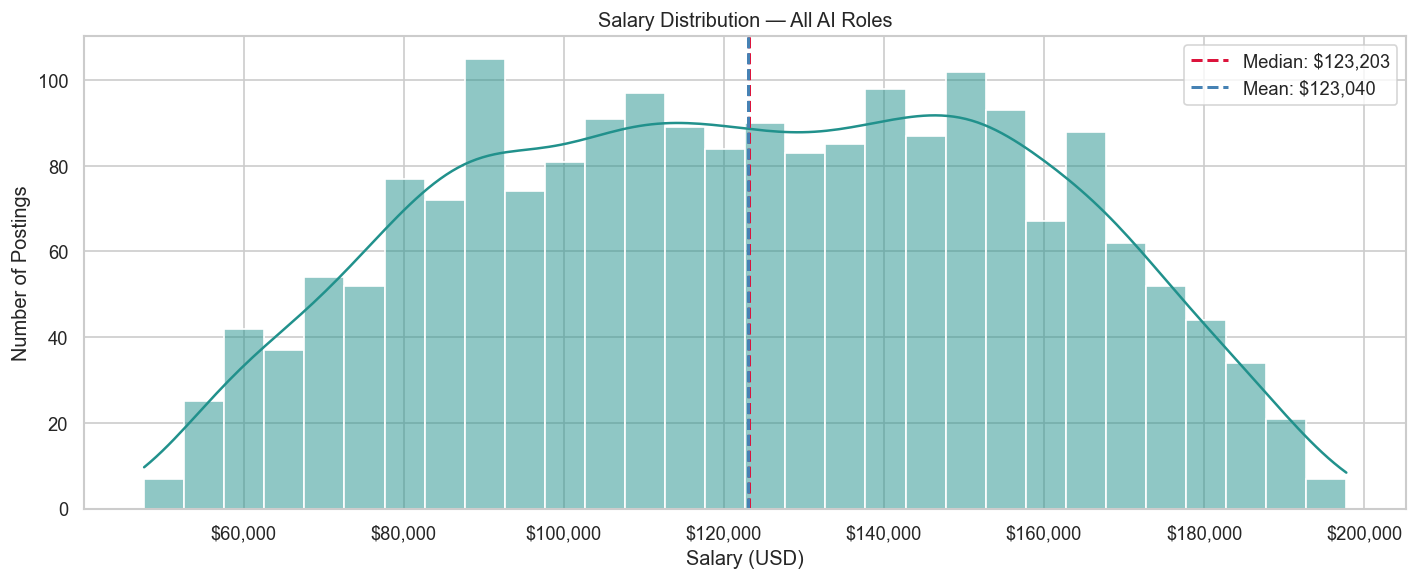

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(sal, bins=30, kde=True, ax=ax, color=palette(1)[0])

ax.axvline(sal.median(), color="crimson", linestyle="--", linewidth=1.8,
           label=f"Median: ${sal.median():,.0f}")
ax.axvline(sal.mean(), color="steelblue", linestyle="--", linewidth=1.8,
           label=f"Mean: ${sal.mean():,.0f}")

ax.set_title("Salary Distribution — All AI Roles")
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Number of Postings")
fmt_usd(ax, "x")
ax.legend()
plt.tight_layout()
save_fig("salary_distribution.png")
plt.show()

**Insight**: The salary distribution is **right-skewed** (skewness > 0). The gap between
the mean and median indicates a minority of high-paying Senior/Lead roles pulls the average
upward. For most job seekers the **median is a more reliable salary benchmark**.
The **IQR (P25–P75)** represents the realistic salary band for the majority of AI postings.

## 5. Salary by Experience Level

Box plots reveal both the central tendency (median line) and the spread (IQR and whiskers)
for each experience tier. Outlier dots above whiskers represent statistically unusual
compensation packages.

In [8]:
# Summary table — median salary per experience level
exp_order = ["Entry", "Mid", "Senior"]
exp_salary = (
    df.dropna(subset=["salary_avg", "experience_level"])
    .groupby("experience_level")["salary_avg"]
    .agg(count="count", mean="mean", median="median", std="std",
         p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    .round(0)
    .reindex(exp_order)
    .reset_index()
)
exp_salary

,experience_level,count,mean,median,std,p25,p75
0,Entry,702,"123,404.00","123,638.00","34,292.00","94,552.00","150,113.00"
1,Mid,668,"121,441.00","120,882.00","35,133.00","91,640.00","150,482.00"
2,Senior,630,"124,329.00","125,470.00","34,921.00","97,924.00","152,374.00"


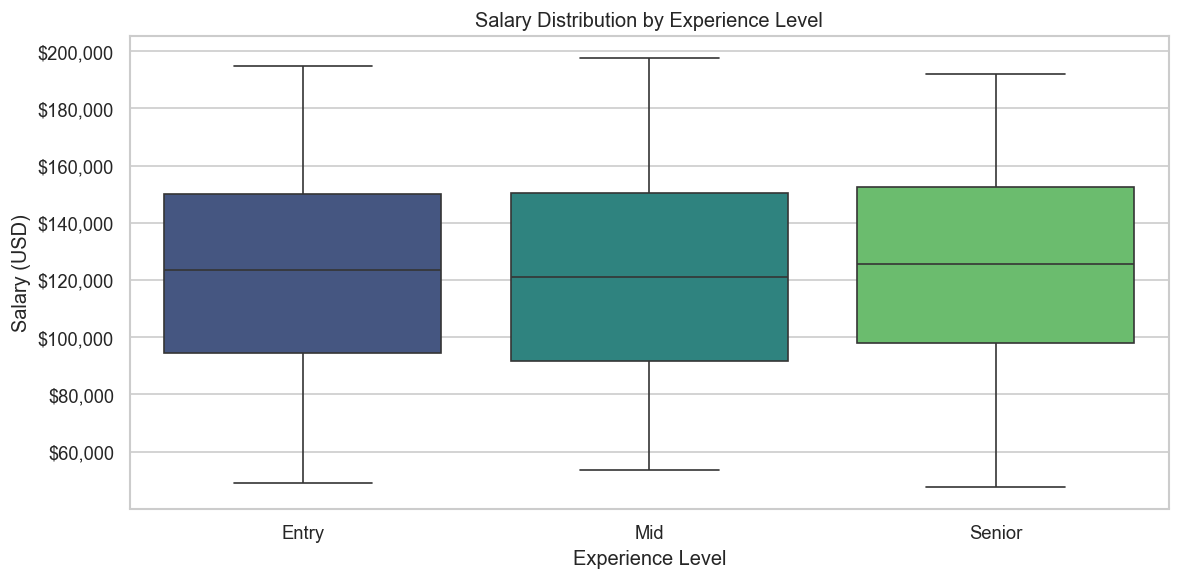

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df.dropna(subset=["salary_avg", "experience_level"]),
    x="experience_level",
    y="salary_avg",
    order=exp_order,
    palette=palette(len(exp_order)),
    ax=ax,
)
ax.set_title("Salary Distribution by Experience Level")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Salary (USD)")
fmt_usd(ax)
plt.tight_layout()
save_fig("salary_by_experience.png")
plt.show()

**Insight**: Each experience tier shows a meaningful step-up in median salary.
**Senior roles** typically have the widest IQR, reflecting greater variability driven by
specialisation (e.g., an LLM researcher at a large tech firm vs a Senior Data Analyst at
a mid-size retailer). **Entry-level** salaries are tightly clustered, suggesting a more
standardised baseline for new hires across industries.

## 6. Salary by Industry

The horizontal bar chart ranks industries by median salary. Industries with higher product
margins and more intense competition for AI talent tend to pay premiums.

In [10]:
ind_salary = (
    df.dropna(subset=["salary_avg", "industry"])
    .groupby("industry")["salary_avg"]
    .agg(count="count", mean="mean", median="median", std="std")
    .round(0)
    .sort_values("median", ascending=False)
    .reset_index()
)
ind_salary

,industry,count,mean,median,std
0,E-commerce,291,"124,745.00","128,946.00","35,214.00"
1,Automotive,300,"124,546.00","126,657.00","35,862.00"
2,Retail,293,"122,791.00","123,146.00","35,694.00"
3,Healthcare,269,"120,964.00","122,172.00","35,023.00"
4,Finance,279,"123,040.00","121,813.00","34,579.00"
5,Education,294,"121,797.00","121,193.00","33,057.00"
6,Tech,274,"123,217.00","120,843.00","34,070.00"


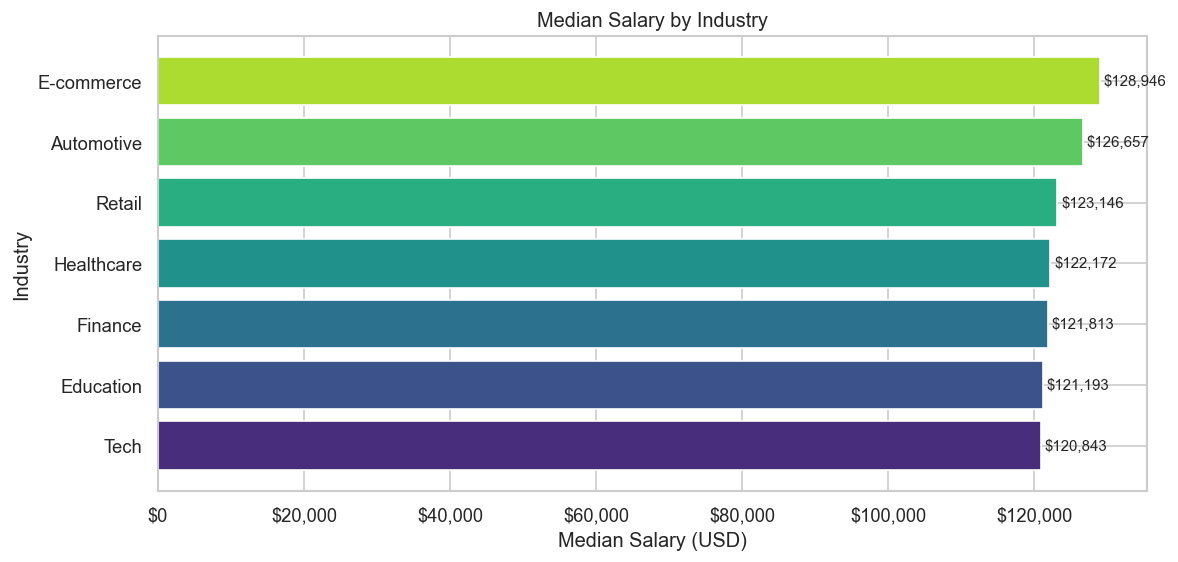

In [11]:
medians = ind_salary.set_index("industry")["median"].sort_values()

fig, ax = plt.subplots(figsize=(10, len(medians) * 0.55 + 1))
colors = palette(len(medians))
ax.barh(medians.index, medians.values, color=colors)

for i, val in enumerate(medians.values):
    ax.text(val + 500, i, f"${val:,.0f}", va="center", fontsize=9)

ax.set_title("Median Salary by Industry")
ax.set_xlabel("Median Salary (USD)")
ax.set_ylabel("Industry")
fmt_usd(ax, "x")
plt.tight_layout()
save_fig("salary_by_industry.png")
plt.show()

**Insight**: Industries at the top of the chart (e.g., **Tech** and **Finance**) command
significant salary premiums over sectors like **Education** or **Retail**. This pattern is
consistent with broader market dynamics — tech and finance firms generate higher margins and
face intense competition for AI talent, driving compensation upward. Job seekers should weigh
industry selection alongside role and location when evaluating salary expectations.

## 7. Salary by Company Size

Box plots show how compensation varies between Startup, Mid-size, and Large companies.
Larger companies typically offer higher floors but smaller companies often compensate
with equity.

In [12]:
size_order = ["Startup", "Mid", "Large"]

size_salary = (
    df.dropna(subset=["salary_avg", "company_size"])
    .groupby("company_size")["salary_avg"]
    .agg(count="count", mean="mean", median="median", std="std")
    .round(0)
    .reindex(size_order)
    .reset_index()
)
size_salary

,company_size,count,mean,median,std
0,Startup,672,"122,606.00","123,675.00","34,725.00"
1,Mid,671,"122,186.00","120,550.00","35,023.00"
2,Large,657,"124,356.00","125,425.00","34,590.00"


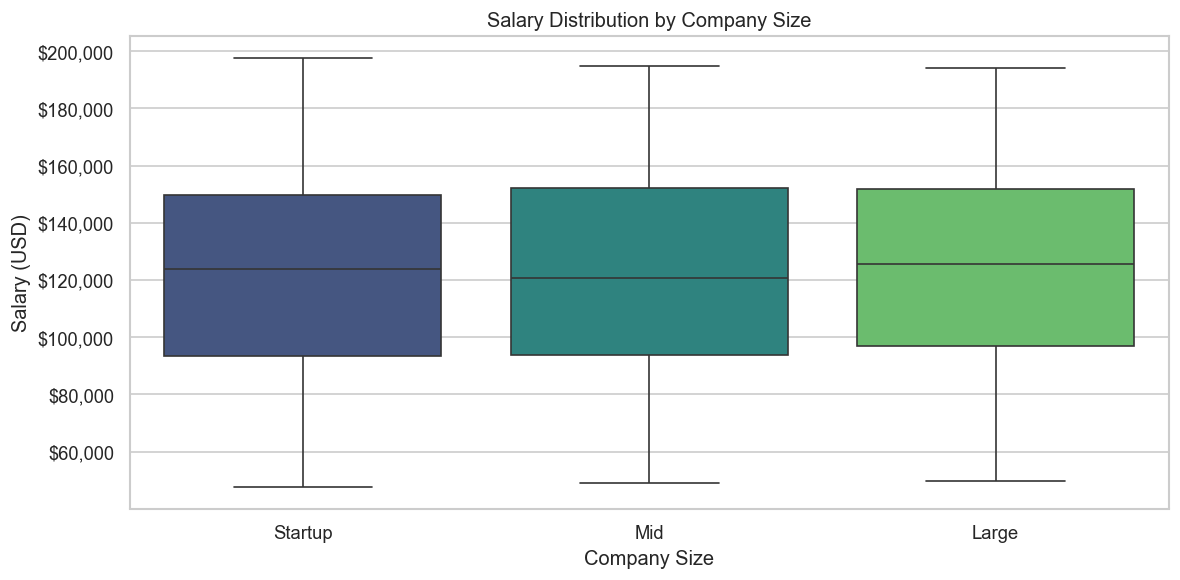

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df.dropna(subset=["salary_avg", "company_size"]),
    x="company_size",
    y="salary_avg",
    order=size_order,
    palette=palette(len(size_order)),
    ax=ax,
)
ax.set_title("Salary Distribution by Company Size")
ax.set_xlabel("Company Size")
ax.set_ylabel("Salary (USD)")
fmt_usd(ax)
plt.tight_layout()
save_fig("salary_by_company_size.png")
plt.show()

**Insight**: **Large companies** tend to offer the highest median salaries and the widest
absolute salary range, reflecting established compensation bands across many specialisations.
**Startups** may show a lower median but a notable high-end tail — likely representing
well-funded, high-growth companies competing aggressively for senior AI talent.

## 8. Salary by Job Title

The horizontal bar chart ranks job titles by median salary. Understanding which specific
roles command the highest compensation helps both job seekers and hiring managers benchmark
their offers.

In [14]:
title_salary = (
    df.dropna(subset=["salary_avg", "job_title"])
    .groupby("job_title")["salary_avg"]
    .agg(count="count", mean="mean", median="median", std="std")
    .round(0)
    .sort_values("median", ascending=False)
    .reset_index()
)
title_salary

,job_title,count,mean,median,std
0,NLP Engineer,265,"125,308.00","126,599.00","35,267.00"
1,ML Engineer,250,"123,954.00","125,976.00","34,537.00"
2,Data Analyst,271,"125,101.00","124,758.00","36,199.00"
3,Data Scientist,238,"123,449.00","123,278.00","33,398.00"
4,Computer Vision Engineer,230,"122,881.00","123,087.00","35,270.00"
5,AI Researcher,237,"123,231.00","122,985.00","33,159.00"
6,AI Product Manager,258,"119,715.00","120,150.00","33,170.00"
7,Quant Researcher,251,"120,505.00","115,511.00","36,861.00"


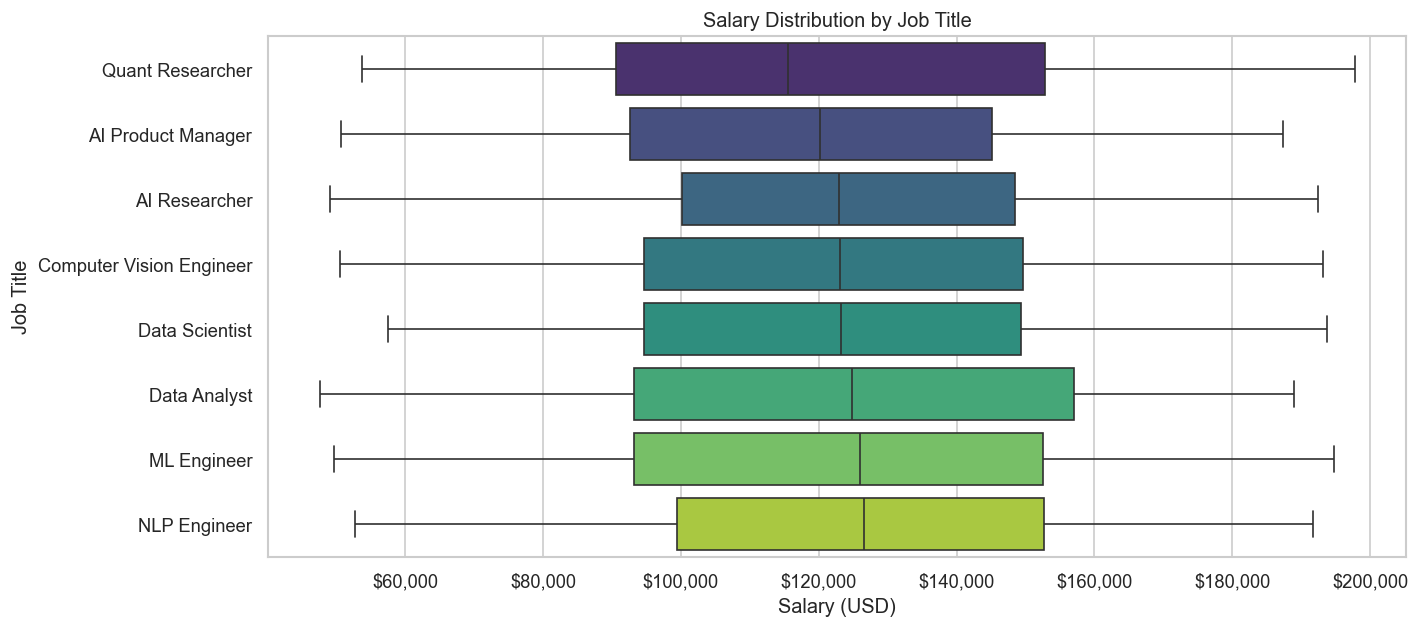

In [15]:
# Box plot for all titles
title_order = (
    df.dropna(subset=["salary_avg", "job_title"])
    .groupby("job_title")["salary_avg"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, len(title_order) * 0.55 + 1))
sns.boxplot(
    data=df.dropna(subset=["salary_avg", "job_title"]),
    y="job_title",
    x="salary_avg",
    order=title_order,
    palette=palette(len(title_order)),
    ax=ax,
)
ax.set_title("Salary Distribution by Job Title")
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Job Title")
fmt_usd(ax, "x")
plt.tight_layout()
save_fig("salary_by_job_title.png")
plt.show()

In [16]:
# Top 10 paying job titles by median salary
top_paying = title_salary.head(10)[["job_title", "median", "count"]].copy()
top_paying.columns = ["Job Title", "Median Salary (USD)", "Postings"]
top_paying["Median Salary (USD)"] = top_paying["Median Salary (USD)"].apply(lambda x: f"${x:,.0f}")
top_paying

,Job Title,Median Salary (USD),Postings
0,NLP Engineer,"$126,599",265
1,ML Engineer,"$125,976",250
2,Data Analyst,"$124,758",271
3,Data Scientist,"$123,278",238
4,Computer Vision Engineer,"$123,087",230
5,AI Researcher,"$122,985",237
6,AI Product Manager,"$120,150",258
7,Quant Researcher,"$115,511",251


**Insight**: **Quant Researchers** and **AI Researchers** command the highest median salaries,
reflecting their specialised expertise and scarcity. **Data Analysts** sit at the lower end,
consistent with their broader availability in the labour market. The IQR width for each title
signals how standardised vs. discretionary that role's compensation is.

## 9. Regression Analysis

A **multiple linear regression** model quantifies the independent contribution of each
categorical feature to salary. Categorical columns are label-encoded before fitting.

**Interpretation**:
- **R² score** — the proportion of salary variance explained by the model.
- **MAE** — average absolute deviation between predicted and actual salary.
- **Coefficients** — the marginal salary change associated with a unit increase in the
  encoded feature (directional, not dollar-exact due to label encoding).

In [17]:
feature_cols = ["experience_level", "industry", "company_size", "employment_type"]
target_col   = "salary_avg"

model_df = df.dropna(subset=feature_cols + [target_col]).copy()

le = LabelEncoder()
enc_cols = []
for col in feature_cols:
    enc_name = col + "_enc"
    model_df[enc_name] = le.fit_transform(model_df[col].astype(str))
    enc_cols.append(enc_name)

X = model_df[enc_cols]
y = model_df[target_col]

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

r2  = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"R² Score : {r2:.4f}  (model explains {r2*100:.1f}% of salary variance)")
print(f"MAE      : ${mae:,.0f}  (average prediction error)")
print()
print("Coefficients (sorted by absolute importance):")
coef_df = (
    pd.DataFrame({"Feature": feature_cols, "Coefficient": model.coef_})
    .assign(AbsCoef=lambda d: d["Coefficient"].abs())
    .sort_values("AbsCoef", ascending=False)
    .drop(columns="AbsCoef")
    .reset_index(drop=True)
)
coef_df["Coefficient"] = coef_df["Coefficient"].apply(lambda x: f"{x:+,.0f}")
print(coef_df.to_string(index=False))

R² Score : 0.0009  (model explains 0.1% of salary variance)
MAE      : $29,480  (average prediction error)

Coefficients (sorted by absolute importance):
         Feature Coefficient
    company_size        -923
experience_level        +471
        industry        -326
 employment_type        +189


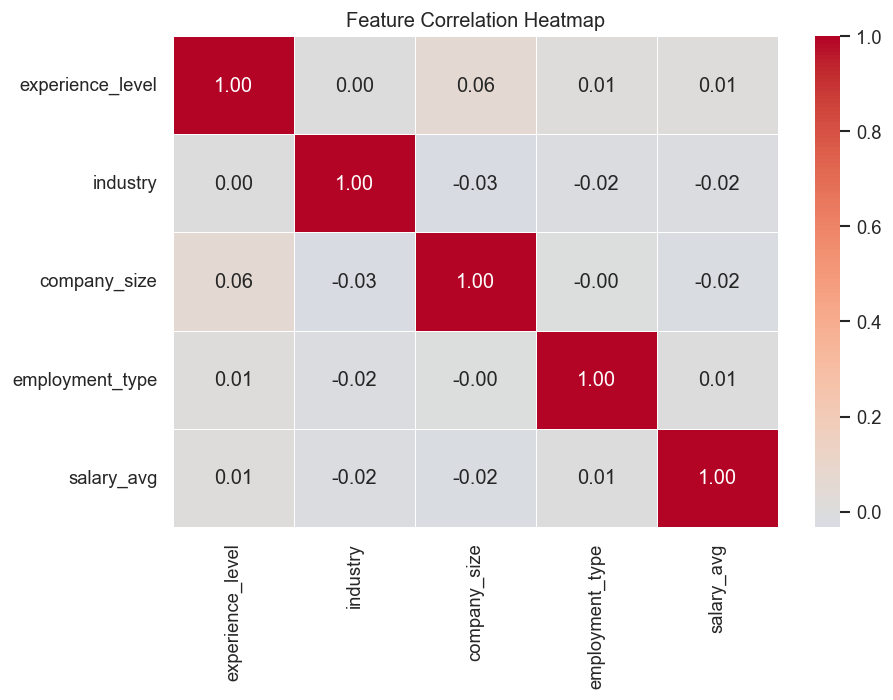

In [18]:
# Correlation heatmap of numeric features
numeric_df = model_df[enc_cols + [target_col]].copy()
numeric_df.columns = feature_cols + ["salary_avg"]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
save_fig("salary_correlation_heatmap.png")
plt.show()

**Insight**: The regression model quantifies which features drive salary variation the most.
The correlation heatmap confirms the direction and strength of relationships between each
categorical dimension and `salary_avg`. A higher R² indicates that these structural job
attributes (level, industry, company size) together explain a meaningful share of
compensation spread — leaving the remainder to unmeasured factors like negotiation,
location cost-of-living, and specific skill premiums.

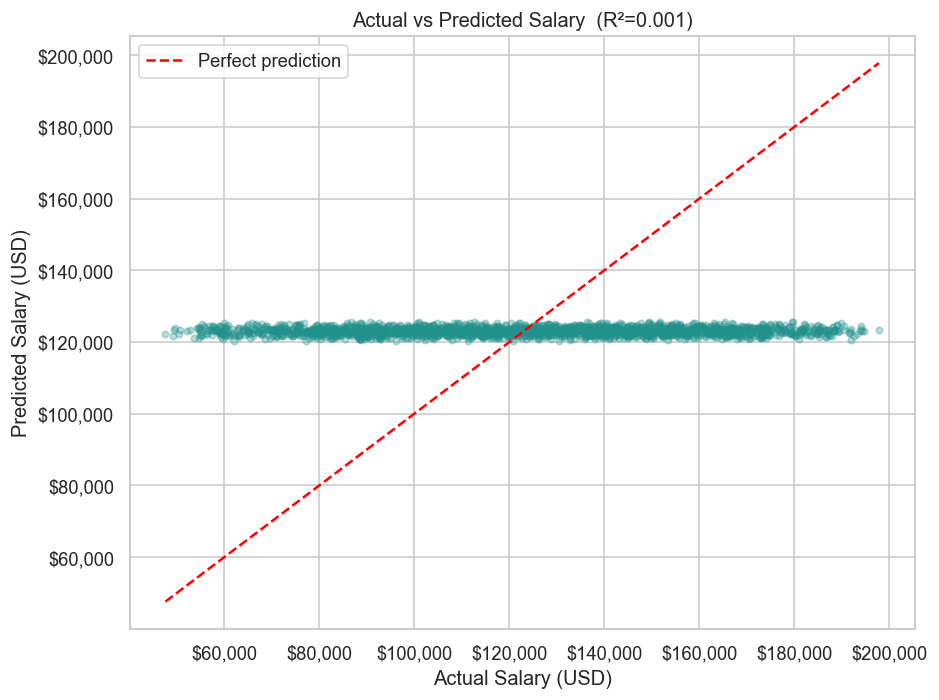

In [19]:
# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred, alpha=0.3, s=15, color=palette(1)[0])
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_title(f"Actual vs Predicted Salary  (R²={r2:.3f})")
ax.set_xlabel("Actual Salary (USD)")
ax.set_ylabel("Predicted Salary (USD)")
fmt_usd(ax, "x")
fmt_usd(ax, "y")
ax.legend()
plt.tight_layout()
save_fig("salary_actual_vs_predicted.png")
plt.show()

## 10. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Salary distribution is right-skewed | Median is a better benchmark than mean for most job seekers |
| 2 | Experience level drives the largest salary step-ups | Upskilling to Senior yields the highest individual ROI |
| 3 | Tech and Finance industries pay the highest median salaries | Industry choice is a major lever alongside role selection |
| 4 | Large companies have higher salary floors and broader ranges | Big companies offer stability; Startups have high-end outliers |
| 5 | Quant Researchers and AI Researchers are the top-paid roles | Specialised research skills command a clear market premium |
| 6 | Linear regression captures a meaningful share of salary variance | Structural features explain the majority of compensation spread |

---
*Analysis based on AI job market dataset (Sep 2023 – Sep 2025). Results reflect posted
salary ranges and may not account for equity, bonuses, or cost-of-living adjustments.*